# Блок «Прогноз»: unsupervised ML
## Autoencoder + Gaussian Mixture + Isolation Forest

Этот ноутбук сделан специально под ситуацию, когда **нет нормального датасета `руда / не руда`**.

Главное отличие от прошлой версии:

- нет `RandomForestClassifier`;
- нет `LogisticRegression`;
- нет псевдометок по `geo_score`;
- модель не обучается повторять вручную размеченную карту;
- итоговая перспективность строится через методы без учителя.

Используются три независимых подхода:

1. **Autoencoder** — нейросеть ищет редкие / сложные сочетания геологических факторов.
2. **Gaussian Mixture Model** — выделяет естественные группы ячеек по факторному пространству.
3. **Isolation Forest** — ищет аномальные сочетания факторов.

Итоговый прогноз — ансамбль этих трёх unsupervised-оценок.


## 1. Импорт библиотек

Если какая-то библиотека не установлена, сначала установи её в своей среде. Обычно нужны:

```bash
pip install geopandas shapely pyproj scikit-learn scipy matplotlib pandas numpy
```


In [35]:
import os
import re
import json
import zipfile
import shutil
import tempfile
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
from pyproj import CRS
from shapely.geometry import box
from shapely.ops import unary_union
from shapely.prepared import prep

from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)


## 2. Настройки

Главные параметры, которые можно менять:

- `CELL_SIZE = 500` — размер ячейки прогноза, как в постановке задачи;
- `GMM_COMPONENT_RANGE` — диапазон количества кластеров для Gaussian Mixture;
- `AUTOENCODER_HIDDEN` — архитектура нейросети-автоэнкодера;
- `WEIGHT_*` — веса трёх unsupervised-методов в итоговом ансамбле.

`BASE_DIR_MANUAL` можно оставить `None`, тогда ноутбук сам попробует найти папку `shp_dbf` или архив `Прогноз.zip`.


In [36]:
# =========================
# ОСНОВНЫЕ НАСТРОЙКИ
# =========================
CELL_SIZE = 500
RANDOM_STATE = 42

# Если авто-поиск не сработал, укажи путь вручную:
# BASE_DIR_MANUAL = Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз")
BASE_DIR_MANUAL = None

# Gaussian Mixture: число компонент выбирается автоматически по BIC.
GMM_COMPONENT_RANGE = range(3, 11)
GMM_COVARIANCE_TYPE = "full"
GMM_N_INIT = 5

# Autoencoder через MLPRegressor: вход = выход.
AUTOENCODER_HIDDEN = (10, 5, 10)
AUTOENCODER_MAX_ITER = 1200
AUTOENCODER_ALPHA = 1e-4
AUTOENCODER_LR = 1e-3
AUTOENCODER_PATIENCE = 50

# Isolation Forest.
ISOLATION_N_ESTIMATORS = 600
ISOLATION_CONTAMINATION = 0.10

# Веса итогового ансамбля.
WEIGHT_AUTOENCODER = 0.45
WEIGHT_GMM = 0.30
WEIGHT_ISOLATION = 0.25

# Сглаживание карты. 0 — без сглаживания.
SMOOTH_PASSES = 3

# Вывод и визуализация.
N_DISPLAY_CLASSES = 20
SHOW_POINTS = True
EXPORT_GPKG = True

OUT_FOLDER_NAME = "unsupervised_forecast_result"


## 3. Поиск исходных данных

Ноутбук ищет данные в нескольких вариантах:

1. рядом с ноутбуком есть папка `shp_dbf`;
2. рядом с ноутбуком есть архив `Прогноз.zip`;
3. данные лежат по старому пути `C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз`;
4. если запуск идёт в среде ChatGPT, данные берутся из `/mnt/data`.


In [37]:
def find_base_dir() -> Path:
    candidates = []

    if BASE_DIR_MANUAL is not None:
        candidates.append(Path(BASE_DIR_MANUAL))

    candidates.extend([
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/prog_zip"),
        Path("/mnt/data"),
        Path(r"C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз"),
    ])

    for base in candidates:
        shp_dir = base / "shp_dbf"
        if shp_dir.exists() and (shp_dir / "svita_new.shp").exists():
            return base

    zip_candidates = [
        Path.cwd() / "Прогноз.zip",
        Path.cwd().parent / "Прогноз.zip",
        Path("/mnt/data/Прогноз.zip"),
    ]

    for zip_path in zip_candidates:
        if zip_path.exists():
            unzip_dir = Path("/mnt/data/prog_zip") if str(zip_path).startswith("/mnt/data") else Path.cwd() / "prog_zip"
            unzip_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(unzip_dir)

            for base in [unzip_dir, *unzip_dir.rglob("*")]:
                shp_dir = base / "shp_dbf"
                if shp_dir.exists() and (shp_dir / "svita_new.shp").exists():
                    return base

    raise FileNotFoundError(
        "Не найден каталог shp_dbf. Положи рядом с ноутбуком папку shp_dbf или архив Прогноз.zip."
    )

BASE_DIR = find_base_dir()
SHP_DIR = BASE_DIR / "shp_dbf"
OUT_DIR = BASE_DIR / OUT_FOLDER_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

TMP_ALIAS_DIR = Path(tempfile.mkdtemp(prefix="prognoz_alias_"))

OUT_PNG = OUT_DIR / "forecast_unsupervised_autoencoder_gmm_iforest.png"
OUT_GPKG = OUT_DIR / "forecast_unsupervised_autoencoder_gmm_iforest.gpkg"
OUT_CSV = OUT_DIR / "grid_attributes_unsupervised.csv"
OUT_JSON = OUT_DIR / "diagnostics_unsupervised.json"

print("BASE_DIR:", BASE_DIR)
print("SHP_DIR:", SHP_DIR)
print("OUT_DIR:", OUT_DIR)


BASE_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз
SHP_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\shp_dbf
OUT_DIR: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result


## 4. Вспомогательные функции

Здесь собраны технические функции:

- загрузка слоёв;
- чтение CRS из файлов `*_shp.pj4`;
- исправление геометрий;
- построение сетки 500×500;
- расчёт расстояний до геологических факторов;
- нормализация;
- сглаживание результата;
- выделение крупных перспективных зон.


In [38]:
def normalize_01(values):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if finite.sum() == 0:
        return np.zeros_like(arr, dtype=float)
    mn = np.nanmin(arr[finite])
    mx = np.nanmax(arr[finite])
    if np.isclose(mx, mn):
        return np.full_like(arr, 0.5, dtype=float)
    out = np.full_like(arr, np.nan, dtype=float)
    out[finite] = (arr[finite] - mn) / (mx - mn)
    return out


def robust_normalize_01(values, q_low=0.02, q_high=0.98):
    arr = np.asarray(values, dtype=float)
    finite = np.isfinite(arr)
    if finite.sum() == 0:
        return np.zeros_like(arr, dtype=float)
    lo = np.nanquantile(arr[finite], q_low)
    hi = np.nanquantile(arr[finite], q_high)
    if not np.isfinite(lo) or not np.isfinite(hi) or np.isclose(lo, hi):
        return normalize_01(arr)
    return np.clip((arr - lo) / (hi - lo), 0, 1)


def smooth_on_regular_grid(grid, value_col, shape, passes=1):
    if passes <= 0:
        return grid[value_col].to_numpy()

    try:
        from scipy.signal import convolve2d
    except Exception:
        print("scipy не найден: сглаживание пропущено")
        return grid[value_col].to_numpy()

    arr = np.full(shape, np.nan, dtype=float)
    rows = grid["row"].to_numpy()
    cols = grid["col"].to_numpy()
    arr[rows, cols] = grid[value_col].to_numpy()

    kernel = np.array([
        [1.0, 1.2, 1.0],
        [1.2, 3.0, 1.2],
        [1.0, 1.2, 1.0],
    ], dtype=float)

    smoothed = arr.copy()
    for _ in range(max(1, passes)):
        valid = np.isfinite(smoothed).astype(float)
        filled = np.nan_to_num(smoothed, nan=0.0)
        num = convolve2d(filled, kernel, mode="same", boundary="fill", fillvalue=0)
        den = convolve2d(valid, kernel, mode="same", boundary="fill", fillvalue=0)
        smoothed = np.where(den > 0, num / den, np.nan)

    return smoothed[rows, cols]


def keep_large_components(grid, bool_col, shape, min_cells=4):
    try:
        from scipy import ndimage
    except Exception:
        return grid[bool_col].to_numpy().astype(bool)

    arr = np.zeros(shape, dtype=np.uint8)
    rows = grid["row"].to_numpy()
    cols = grid["col"].to_numpy()
    arr[rows, cols] = grid[bool_col].to_numpy().astype(np.uint8)

    structure = np.ones((3, 3), dtype=np.uint8)
    labeled, _ = ndimage.label(arr, structure=structure)
    sizes = np.bincount(labeled.ravel())
    keep_ids = np.where(sizes >= min_cells)[0]
    keep = np.isin(labeled, keep_ids) & (labeled > 0)
    return keep[rows, cols]


def read_sidecar_proj4(shp_path: Path):
    sidecar = shp_path.with_name(shp_path.stem + "_shp.pj4")
    if sidecar.exists():
        txt = sidecar.read_text(encoding="utf-8", errors="ignore")
        m = re.search(r"pj4=(.+)", txt)
        if m:
            return m.group(1).strip()
    return None


def prepare_ascii_aliases(shp_dir: Path, alias_dir: Path):
    """
    В архиве есть слои с битой кодировкой в имени.
    Для geopandas удобнее временно скопировать их под простыми именами layer_00, layer_01...
    """
    aliases, stems = {}, {}

    for name_b in os.listdir(os.fsencode(shp_dir)):
        if not name_b.endswith((b".shp", b".shx", b".dbf", b".prj", b".pj4")):
            continue
        if name_b.endswith(b"_shp.pj4"):
            continue
        base_b, ext_b = os.path.splitext(name_b)
        stems.setdefault(base_b, set()).add(ext_b)

    alias_idx = 0
    for base_b, exts in sorted(stems.items()):
        try:
            base_s = os.fsdecode(base_b)
            safe = all(ord(ch) < 128 and (ch.isalnum() or ch in "_-. ") for ch in base_s)
        except Exception:
            safe = False
            base_s = None

        if safe:
            aliases[base_s] = shp_dir / f"{base_s}.shp"
            continue

        alias = f"layer_{alias_idx:02d}"
        alias_idx += 1

        for ext_b in exts:
            src = os.path.join(os.fsencode(shp_dir), base_b + ext_b)
            dst = alias_dir / f"{alias}{os.fsdecode(ext_b)}"
            shutil.copyfile(src, dst)

        pj4_src = os.path.join(os.fsencode(shp_dir), base_b + b"_shp.pj4")
        if os.path.exists(pj4_src):
            shutil.copyfile(pj4_src, alias_dir / f"{alias}_shp.pj4")

        aliases[alias] = alias_dir / f"{alias}.shp"

    return aliases


def repair_geometries(gdf):
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    if len(gdf) == 0:
        return gdf
    try:
        gdf["geometry"] = gdf.geometry.make_valid()
    except Exception:
        gdf["geometry"] = gdf.geometry.buffer(0)
    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf = gdf[~gdf.geometry.is_empty].copy()
    return gdf


def load_layer(path: Path):
    gdf = gpd.read_file(path)
    gdf = repair_geometries(gdf)

    if gdf.crs is None:
        proj4 = read_sidecar_proj4(path)
        if proj4:
            gdf = gdf.set_crs(CRS.from_proj4(proj4), allow_override=True)
        else:
            print(f"CRS не найден и pj4 не найден: {path.name}")

    return gdf


def to_crs_safe(gdf, target_crs):
    if gdf.crs is None and target_crs is not None:
        return gdf.set_crs(target_crs, allow_override=True)
    if target_crs is None or gdf.crs == target_crs:
        return gdf
    return gdf.to_crs(target_crs)


def finite_bounds(gdf, layer_name="layer"):
    bounds = np.asarray(gdf.total_bounds, dtype=float)
    if len(bounds) != 4 or not np.all(np.isfinite(bounds)):
        raise ValueError(f"Некорректные total_bounds у {layer_name}: {bounds}")
    minx, miny, maxx, maxy = bounds
    if maxx <= minx or maxy <= miny:
        raise ValueError(f"Пустые или некорректные границы у {layer_name}: {bounds}")
    return minx, miny, maxx, maxy


def build_grid(mask_gdf, cell_size=500):
    mask_gdf = repair_geometries(mask_gdf)
    mask_union = unary_union(mask_gdf.geometry)
    prepared_mask = prep(mask_union)

    minx, miny, maxx, maxy = finite_bounds(mask_gdf, "mask")
    xs = np.arange(minx, maxx, cell_size)
    ys = np.arange(miny, maxy, cell_size)

    rows = []
    cell_id = 0
    for r, y in enumerate(ys):
        for c, x in enumerate(xs):
            geom = box(x, y, x + cell_size, y + cell_size)
            if prepared_mask.intersects(geom):
                rows.append((cell_id, r, c, geom))
                cell_id += 1

    grid = gpd.GeoDataFrame(
        rows,
        columns=["cell_id", "row", "col", "geometry"],
        geometry="geometry",
        crs=mask_gdf.crs,
    )
    return grid, mask_union, (len(ys), len(xs))


def add_distance_feature(grid, source_gdf, name):
    source_gdf = repair_geometries(source_gdf)
    source_union = unary_union(source_gdf.geometry)
    distances = np.empty(len(grid), dtype=float)

    # Считаем расстояние от ячейки до объекта. Если ячейка пересекает объект, расстояние 0.
    for i, geom in enumerate(grid.geometry.values):
        distances[i] = 0.0 if geom.intersects(source_union) else geom.distance(source_union)

    grid[name] = distances
    return grid


def distance_to_proximity(distance, transform="sqrt", q=0.75):
    """
    Перевод расстояния в близость:
    расстояние 0 -> близость около 1;
    большие расстояния -> близость к 0.
    """
    d = np.asarray(distance, dtype=float)
    d = np.clip(d, 0, None)

    if transform == "sqrt":
        t = np.sqrt(d)
    elif transform == "cbrt":
        t = np.cbrt(d)
    else:
        t = d

    scale = float(np.nanquantile(t, q))
    if not np.isfinite(scale) or scale <= 0:
        scale = max(float(np.nanmean(t)), 1.0)

    return np.clip(np.exp(-t / scale), 0, 1)


def collect_points(mask_crs, aliases):
    """
    Собираем все точечные слои, кроме основных факторных.
    Они не используются для обучения, а только для проверки попадания результата.
    """
    base_names = {
        "svita_new", "fasii", "glub_raz_nw", "glub_r_nw",
        "gr_dol_vp_poly", "kory", "dayki_buf",
    }
    layers = []

    for name, shp_path in aliases.items():
        if name in base_names:
            continue
        try:
            gdf = to_crs_safe(load_layer(shp_path), mask_crs)
        except Exception as exc:
            print(f"Не удалось прочитать слой {name}: {exc}")
            continue

        geom_types = {str(x) for x in gdf.geom_type.unique()}
        if "Point" in geom_types or "MultiPoint" in geom_types:
            gdf = gdf.copy()
            gdf["source_layer"] = name
            layers.append(gdf)

    if not layers:
        return None

    pts = pd.concat(layers, ignore_index=True)
    return gpd.GeoDataFrame(pts, geometry="geometry", crs=mask_crs)


def set_mask_extent(ax, mask_gdf):
    minx, miny, maxx, maxy = mask_gdf.total_bounds
    padx = (maxx - minx) * 0.02
    pady = (maxy - miny) * 0.02
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)


## 5. Загрузка слоёв

Используются те же факторные слои:

- `svita_new` — область / маска прогноза;
- `fasii` — литолого-фациальный фактор;
- `gr_dol_vp_poly` — палеогеоморфологический фактор;
- `kory` — структурно-литологический фактор;
- `dayki_buf` — магматогенный фактор;
- `glub_raz_nw` и `glub_r_nw` — тектонические факторы.

Точечные слои собираются отдельно и **не используются для обучения**, только для проверки попадания известных проявлений в верхние зоны прогноза.


In [39]:
aliases = prepare_ascii_aliases(SHP_DIR, TMP_ALIAS_DIR)
print("Найденные слои:", sorted(aliases.keys()))

required = ["svita_new", "fasii", "glub_raz_nw", "glub_r_nw", "gr_dol_vp_poly", "kory", "dayki_buf"]
missing = [name for name in required if name not in aliases]
if missing:
    raise FileNotFoundError(f"Не найдены обязательные слои: {missing}")

mask = load_layer(aliases["svita_new"])
facies = to_crs_safe(load_layer(aliases["fasii"]), mask.crs)
paleo = to_crs_safe(load_layer(aliases["gr_dol_vp_poly"]), mask.crs)
struct = to_crs_safe(load_layer(aliases["kory"]), mask.crs)
magm = to_crs_safe(load_layer(aliases["dayki_buf"]), mask.crs)
tect1 = to_crs_safe(load_layer(aliases["glub_raz_nw"]), mask.crs)
tect2 = to_crs_safe(load_layer(aliases["glub_r_nw"]), mask.crs)
points = collect_points(mask.crs, aliases)

print("CRS:", mask.crs)
print("mask:", len(mask))
print("facies:", len(facies))
print("paleo:", len(paleo))
print("struct:", len(struct))
print("magm:", len(magm))
print("tect1:", len(tect1))
print("tect2:", len(tect2))
print("points:", 0 if points is None else len(points))


Найденные слои: ['dayki_buf', 'fasii', 'glub_r_nw', 'glub_raz_nw', 'gr_dol_vp_poly', 'kory', 'layer_00', 'layer_01', 'layer_02', 'result', 'svita_new']
CRS: +proj=tmerc +lon_0=105 +lat_0=0 +x_0=500000 +y_0=0 +k_0=1 +towgs84=23.57,-140.95,-79.8,0,0.35,0.79,-0.22 +ellps=krass +units=m +lon_wrap=45 +no_defs +type=crs
mask: 101
facies: 15
paleo: 6
struct: 19
magm: 151
tect1: 4
tect2: 2
points: 1408


## 6. Сетка 500×500 и расчёт признаков

Каждая ячейка получает набор числовых признаков.

Логика такая:

- сначала считаем расстояние до каждого фактора;
- потом расстояние переводим в близость `prox_*`;
- затем добавляем признаки пересечения / совпадения факторов.

Важно: тут нет целевой переменной `0/1`, нет ручной разметки и нет псевдометок.


In [40]:
grid, mask_union, grid_shape = build_grid(mask, CELL_SIZE)
print("Ячеек в сетке:", len(grid))
print("Форма регулярной сетки:", grid_shape)

for src, name in [
    (facies, "dist_facies"),
    (paleo, "dist_paleo"),
    (struct, "dist_struct"),
    (magm, "dist_magm"),
    (tect1, "dist_tect1"),
    (tect2, "dist_tect2"),
]:
    print("Считаю", name)
    grid = add_distance_feature(grid, src, name)

# Близости к факторам.
# q задаёт характерный масштаб расстояний. Чем меньше q, тем быстрее близость падает с расстоянием.
grid["prox_facies"] = distance_to_proximity(grid["dist_facies"], transform="cbrt", q=0.78)
grid["prox_paleo"] = distance_to_proximity(grid["dist_paleo"], transform="cbrt", q=0.76)
grid["prox_struct"] = distance_to_proximity(grid["dist_struct"], transform="sqrt", q=0.72)
grid["prox_magm"] = distance_to_proximity(grid["dist_magm"], transform="sqrt", q=0.42)
grid["prox_tect1"] = distance_to_proximity(grid["dist_tect1"], transform="cbrt", q=0.74)
grid["prox_tect2"] = distance_to_proximity(grid["dist_tect2"], transform="cbrt", q=0.74)

# Сочетания факторов.
grid["tect_combo"] = 0.5 * (grid["prox_tect1"] + grid["prox_tect2"])
grid["tect_intersection"] = grid["prox_tect1"] * grid["prox_tect2"]
grid["tect_magm_intersection"] = np.sqrt(grid["tect_combo"] * grid["prox_magm"])
grid["tect_struct_intersection"] = np.sqrt(grid["tect_combo"] * grid["prox_struct"])
grid["paleo_struct_intersection"] = np.sqrt(grid["prox_paleo"] * grid["prox_struct"])
grid["paleo_facies_intersection"] = np.sqrt(grid["prox_paleo"] * grid["prox_facies"])

base_prox_cols = [
    "prox_facies", "prox_paleo", "prox_struct", "prox_magm", "prox_tect1", "prox_tect2"
]
prox_matrix = grid[base_prox_cols].to_numpy(dtype=float)
grid["factor_mean"] = np.nanmean(prox_matrix, axis=1)
grid["factor_min"] = np.nanmin(prox_matrix, axis=1)
grid["factor_std"] = np.nanstd(prox_matrix, axis=1)
grid["factor_balance"] = robust_normalize_01(grid["factor_mean"] * (1.0 - normalize_01(grid["factor_std"])), 0.02, 0.98)

combo_core = (
    np.clip(grid["tect_combo"], 0, 1)
    * np.clip(0.55 * grid["prox_magm"] + 0.45 * grid["prox_struct"], 0, 1)
    * np.clip(0.60 * grid["prox_paleo"] + 0.40 * grid["prox_facies"], 0, 1)
)
grid["coincidence_score"] = robust_normalize_01(np.sqrt(np.clip(combo_core, 0, 1)), 0.02, 0.98)

# Штраф за ситуацию, когда есть только тектоника, но нет поддержки магматизма/структур/палеодолин.
tect_support = 0.40 * grid["prox_magm"] + 0.35 * grid["prox_struct"] + 0.25 * grid["prox_paleo"]
grid["tect_only_penalty"] = robust_normalize_01(np.clip(grid["tect_combo"] - tect_support, 0, 1), 0.02, 0.98)

grid[[*base_prox_cols, "coincidence_score", "tect_only_penalty"]].describe().round(3)


Ячеек в сетке: 15684
Форма регулярной сетки: (154, 145)
Считаю dist_facies
Считаю dist_paleo
Считаю dist_struct
Считаю dist_magm
Считаю dist_tect1
Считаю dist_tect2


,prox_facies,prox_paleo,prox_struct,prox_magm,prox_tect1,prox_tect2,coincidence_score,tect_only_penalty
count,15684.000,15684.000,15684.000,15684.000,15684.000,15684.000,15684.000,15684.000
mean,0.601,0.621,0.474,0.424,0.667,0.694,0.357,0.317
std,0.264,0.291,0.147,0.305,0.321,0.328,0.247,0.289
min,0.242,0.208,0.270,0.028,0.134,0.148,0.000,0.000
25%,0.381,0.372,0.359,0.188,0.363,0.361,0.164,0.001
50%,0.514,0.499,0.438,0.310,0.593,1.000,0.315,0.287
75%,1.000,1.000,0.553,0.575,1.000,1.000,0.502,0.515
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 7. Геологический фильтр без обучения

Методы без учителя находят **редкие сочетания**, но не каждое редкое сочетание является перспективным.

Например, ячейка может быть аномальной просто потому, что она далеко от всех факторов. Поэтому нужен мягкий геологический фильтр `support_score`.

Это не целевая разметка и не `pseudo-labels`. Он не говорит модели: «это руда». Он только задаёт направление интерпретации: аномалии с геологической поддержкой важнее, чем аномалии без факторов.


In [41]:
grid["support_raw"] = (
    0.10 * grid["prox_facies"] +
    0.15 * grid["prox_paleo"] +
    0.13 * grid["prox_struct"] +
    0.13 * grid["prox_magm"] +
    0.11 * grid["prox_tect1"] +
    0.11 * grid["prox_tect2"] +
    0.08 * grid["tect_intersection"] +
    0.10 * grid["tect_magm_intersection"] +
    0.06 * grid["tect_struct_intersection"] +
    0.05 * grid["paleo_struct_intersection"] +
    0.08 * grid["coincidence_score"] +
    0.05 * grid["factor_balance"] -
    0.05 * grid["tect_only_penalty"]
)

grid["support_score"] = robust_normalize_01(grid["support_raw"], 0.02, 0.98)
grid["support_score_sm"] = robust_normalize_01(
    smooth_on_regular_grid(grid, "support_score", grid_shape, passes=1), 0.02, 0.98
)

grid[["support_score", "coincidence_score", "factor_balance"]].describe().round(3)


,support_score,coincidence_score,factor_balance
count,15684.000,15684.000,15684.000
mean,0.379,0.357,0.398
std,0.251,0.247,0.235
min,0.000,0.000,0.000
25%,0.184,0.164,0.231
50%,0.340,0.315,0.367
75%,0.545,0.502,0.538
max,1.000,1.000,1.000


## 8. Матрица признаков для методов без учителя

В `X` входят только признаки ячеек. Целевой переменной нет.

`support_score` тоже не входит как отдельный обучающий признак. Он используется позже только для интерпретации аномалий.


In [42]:
feature_cols = [
    "prox_facies", "prox_paleo", "prox_struct", "prox_magm",
    "prox_tect1", "prox_tect2",
    "tect_combo", "tect_intersection",
    "tect_magm_intersection", "tect_struct_intersection",
    "paleo_struct_intersection", "paleo_facies_intersection",
    "coincidence_score", "factor_mean", "factor_min", "factor_balance",
    "tect_only_penalty",
]

X_df = grid[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0.0).copy()
scaler = StandardScaler()
X = scaler.fit_transform(X_df.to_numpy())

print("Размер матрицы признаков:", X.shape)
display(X_df.head())


Размер матрицы признаков: (15684, 17)


,prox_facies,prox_paleo,prox_struct,prox_magm,prox_tect1,prox_tect2,tect_combo,tect_intersection,tect_magm_intersection,tect_struct_intersection,paleo_struct_intersection,paleo_facies_intersection,coincidence_score,factor_mean,factor_min,factor_balance,tect_only_penalty
0,0.447386,0.325855,0.413625,1.0,0.240259,1.0,0.620130,0.240259,0.787483,0.506460,0.367127,0.381816,0.356418,0.571188,0.240259,0.221904,0.000000
1,0.459178,0.325615,0.417485,1.0,0.246081,1.0,0.623041,0.246081,0.789329,0.510010,0.368700,0.386672,0.364020,0.574727,0.246081,0.235054,0.000000
2,0.472161,0.324826,0.421422,1.0,0.252258,1.0,0.626129,0.252258,0.791283,0.513678,0.369985,0.391625,0.371912,0.578444,0.252258,0.248561,0.000000
3,0.486601,0.323507,0.425440,1.0,0.259099,1.0,0.629549,0.259099,0.793442,0.517529,0.370989,0.396760,0.380321,0.582441,0.259099,0.262766,0.000000
4,0.502865,0.321694,0.429543,1.0,0.266433,1.0,0.633216,0.266433,0.795749,0.521530,0.371727,0.402205,0.389368,0.586756,0.266433,0.277527,0.003541


## 9. PCA-диагностика

PCA здесь не является главным методом прогноза. Он нужен, чтобы понять, есть ли структура в признаках и насколько данные сжимаются в несколько направлений.


,component,explained_variance_ratio,cumulative
0,PC1,0.369,0.369
1,PC2,0.208,0.576
2,PC3,0.155,0.732
3,PC4,0.094,0.826
4,PC5,0.060,0.886
5,PC6,0.052,0.938


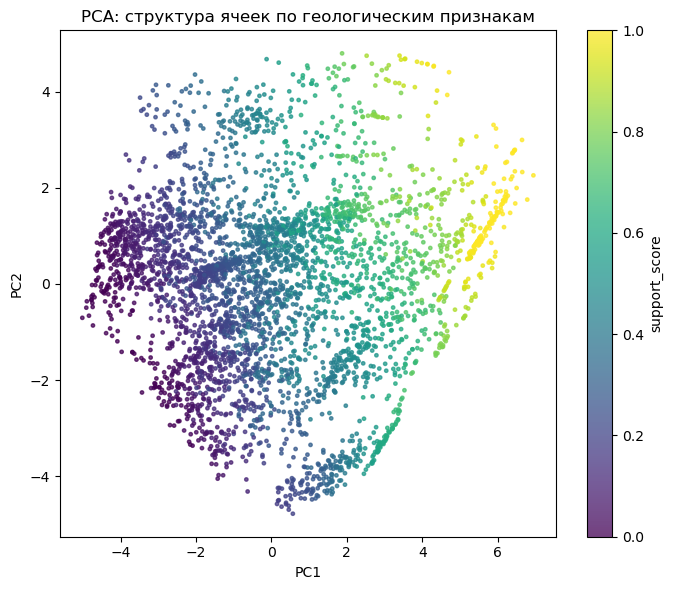

In [43]:
pca_n = min(6, X.shape[1])
pca = PCA(n_components=pca_n, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

grid["pca1"] = X_pca[:, 0]
grid["pca2"] = X_pca[:, 1]

pca_df = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(pca_n)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative": np.cumsum(pca.explained_variance_ratio_),
})
display(pca_df.round(3))

sample_n = min(4000, len(grid))
sample = grid.sample(sample_n, random_state=RANDOM_STATE)
plt.figure(figsize=(7, 6))
plt.scatter(sample["pca1"], sample["pca2"], c=sample["support_score"], s=6, alpha=0.75)
plt.colorbar(label="support_score")
plt.title("PCA: структура ячеек по геологическим признакам")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


## 10. Gaussian Mixture Model

GMM ищет естественные группы ячеек в пространстве факторов.

Количество компонент выбирается по BIC: чем меньше BIC, тем лучше баланс между качеством описания данных и сложностью модели.

После кластеризации каждому кластеру даётся оценка перспективности по средним значениям факторов внутри кластера. Это не supervised-разметка, потому что мы не говорим модели заранее, где руда. Мы только интерпретируем найденные группы.


In [44]:
def fit_best_gmm(X, component_range):
    rows = []
    best_model = None
    best_bic = np.inf

    for k in component_range:
        if k >= len(X):
            continue

        model = GaussianMixture(
            n_components=k,
            covariance_type=GMM_COVARIANCE_TYPE,
            reg_covar=1e-5,
            n_init=GMM_N_INIT,
            max_iter=500,
            random_state=RANDOM_STATE,
        )
        model.fit(X)
        bic = model.bic(X)
        aic = model.aic(X)
        rows.append({"n_components": k, "BIC": bic, "AIC": aic})

        if bic < best_bic:
            best_bic = bic
            best_model = model

    return best_model, pd.DataFrame(rows)


gmm, gmm_selection = fit_best_gmm(X, GMM_COMPONENT_RANGE)
display(gmm_selection.round(1))
print("Выбрано компонент GMM:", gmm.n_components)

grid["gmm_cluster"] = gmm.predict(X)
gmm_prob = gmm.predict_proba(X)

cluster_profiles = grid.groupby("gmm_cluster")[[
    "prox_facies", "prox_paleo", "prox_struct", "prox_magm",
    "prox_tect1", "prox_tect2", "tect_intersection",
    "tect_magm_intersection", "tect_struct_intersection",
    "paleo_struct_intersection", "coincidence_score",
    "factor_balance", "tect_only_penalty", "support_score"
]].mean()

cluster_counts = grid["gmm_cluster"].value_counts().sort_index()
cluster_profiles["n_cells"] = cluster_counts

cluster_profiles["cluster_score_raw"] = (
    0.10 * cluster_profiles["prox_facies"] +
    0.15 * cluster_profiles["prox_paleo"] +
    0.13 * cluster_profiles["prox_struct"] +
    0.13 * cluster_profiles["prox_magm"] +
    0.11 * cluster_profiles["prox_tect1"] +
    0.11 * cluster_profiles["prox_tect2"] +
    0.09 * cluster_profiles["tect_magm_intersection"] +
    0.07 * cluster_profiles["tect_struct_intersection"] +
    0.07 * cluster_profiles["coincidence_score"] +
    0.06 * cluster_profiles["factor_balance"] -
    0.05 * cluster_profiles["tect_only_penalty"]
)

cluster_profiles["cluster_score"] = robust_normalize_01(cluster_profiles["cluster_score_raw"], 0.00, 1.00)

scores_by_cluster = cluster_profiles["cluster_score"].sort_index().to_numpy()
grid["gmm_score"] = robust_normalize_01(gmm_prob @ scores_by_cluster, 0.02, 0.98)
grid["gmm_score_sm"] = robust_normalize_01(smooth_on_regular_grid(grid, "gmm_score", grid_shape, passes=1), 0.02, 0.98)

display(cluster_profiles.sort_values("cluster_score", ascending=False).round(3))


,n_components,BIC,AIC
0,3,-306478.8,-310400.9
1,4,-410885.8,-416117.8
2,5,-493522.8,-500064.8
3,6,-534161.4,-542013.3
4,7,-552572.6,-561734.4
5,8,-603098.4,-613570.1
6,9,-623652.0,-635433.6
7,10,-670455.9,-683547.6


Выбрано компонент GMM: 10


,prox_facies,prox_paleo,prox_struct,prox_magm,prox_tect1,prox_tect2,tect_intersection,tect_magm_intersection,tect_struct_intersection,paleo_struct_intersection,coincidence_score,factor_balance,tect_only_penalty,support_score,n_cells,cluster_score_raw,cluster_score
gmm_cluster,,,,,,,,,,,,,,,,,
0,0.584,0.803,0.483,0.719,1.000,1.000,1.000,0.834,0.691,0.605,0.795,0.723,0.494,0.840,1356,0.753,1.000
9,0.613,1.000,0.431,0.671,0.653,0.745,0.398,0.670,0.546,0.654,0.655,0.472,0.100,0.638,1344,0.676,0.767
4,0.854,0.260,0.750,0.414,0.980,0.246,0.226,0.477,0.676,0.439,0.351,0.157,0.196,0.321,627,0.525,0.310
6,0.608,0.650,0.466,0.224,0.635,1.000,0.635,0.423,0.613,0.536,0.354,0.337,0.581,0.385,2894,0.525,0.309
5,0.505,0.434,0.385,0.635,0.361,1.000,0.361,0.638,0.508,0.405,0.325,0.411,0.274,0.337,1947,0.525,0.308
8,0.359,0.351,0.321,0.548,1.000,1.000,1.000,0.706,0.566,0.333,0.307,0.189,0.827,0.410,1029,0.516,0.282
2,0.538,1.000,0.490,0.179,0.715,0.380,0.264,0.306,0.507,0.692,0.279,0.220,0.138,0.302,1763,0.500,0.234
1,0.647,0.441,0.501,0.336,1.000,0.391,0.391,0.452,0.581,0.461,0.289,0.349,0.397,0.290,1541,0.495,0.219
3,0.637,0.600,0.399,0.500,0.380,0.461,0.172,0.432,0.406,0.479,0.206,0.583,0.064,0.229,1786,0.476,0.162


## 11. Isolation Forest

Isolation Forest ищет ячейки, которые отличаются от основной массы.

Сама по себе аномальность ещё не означает перспективность, поэтому итоговый `isolation_score` усиливается только там, где есть геологическая поддержка `support_score`.


In [45]:
isolation = IsolationForest(
    n_estimators=ISOLATION_N_ESTIMATORS,
    contamination=ISOLATION_CONTAMINATION,
    max_samples="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
isolation.fit(X)

# score_samples: чем меньше значение, тем сильнее аномалия.
iso_anomaly_raw = -isolation.score_samples(X)
grid["isolation_anomaly"] = robust_normalize_01(iso_anomaly_raw, 0.02, 0.98)

# Оставляем аномальность, но повышаем вес только геологически осмысленных аномалий.
grid["isolation_score"] = robust_normalize_01(
    grid["isolation_anomaly"] * (0.35 + 0.65 * grid["support_score_sm"]), 0.02, 0.98
)
grid["isolation_score_sm"] = robust_normalize_01(
    smooth_on_regular_grid(grid, "isolation_score", grid_shape, passes=1), 0.02, 0.98
)

grid[["isolation_anomaly", "isolation_score"]].describe().round(3)


,isolation_anomaly,isolation_score
count,15684.000,15684.000
mean,0.376,0.275
std,0.234,0.224
min,0.000,0.000
25%,0.198,0.115
50%,0.348,0.210
75%,0.519,0.375
max,1.000,1.000


## 12. Autoencoder

Autoencoder — это нейросеть без учителя.

Она получает на вход признаки ячейки и пытается восстановить эти же признаки на выходе.

Если сочетание факторов обычное, сеть восстанавливает его хорошо. Если сочетание редкое или сложное, ошибка восстановления выше. Такая ошибка используется как признак аномальности.


In [46]:
autoencoder = MLPRegressor(
    hidden_layer_sizes=AUTOENCODER_HIDDEN,
    activation="relu",
    solver="adam",
    alpha=AUTOENCODER_ALPHA,
    learning_rate_init=AUTOENCODER_LR,
    max_iter=AUTOENCODER_MAX_ITER,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=AUTOENCODER_PATIENCE,
    random_state=RANDOM_STATE,
    verbose=False,
)

autoencoder.fit(X, X)
X_reconstructed = autoencoder.predict(X)
reconstruction_error = np.mean((X - X_reconstructed) ** 2, axis=1)

grid["ae_reconstruction_error"] = reconstruction_error
grid["ae_anomaly"] = robust_normalize_01(reconstruction_error, 0.02, 0.98)

# Аномалия + геологическая поддержка.
grid["autoencoder_score"] = robust_normalize_01(
    grid["ae_anomaly"] * (0.35 + 0.65 * grid["support_score_sm"]), 0.02, 0.98
)
grid["autoencoder_score_sm"] = robust_normalize_01(
    smooth_on_regular_grid(grid, "autoencoder_score", grid_shape, passes=1), 0.02, 0.98
)

print("Итераций autoencoder:", autoencoder.n_iter_)
grid[["ae_reconstruction_error", "ae_anomaly", "autoencoder_score"]].describe().round(3)


Итераций autoencoder: 611


,ae_reconstruction_error,ae_anomaly,autoencoder_score
count,15684.000,15684.000,15684.000
mean,0.067,0.234,0.239
std,0.060,0.225,0.237
min,0.002,0.000,0.000
25%,0.028,0.079,0.073
50%,0.048,0.161,0.151
75%,0.083,0.308,0.322
max,0.599,1.000,1.000


## 13. Ансамбль трёх методов

Итоговый прогноз собирается из трёх независимых оценок:

```text
prospectivity = 0.45 * Autoencoder + 0.30 * GMM + 0.25 * Isolation Forest
```

После этого применяется лёгкое сглаживание, чтобы убрать пиксельный шум.


In [47]:
weight_sum = WEIGHT_AUTOENCODER + WEIGHT_GMM + WEIGHT_ISOLATION

if weight_sum <= 0:
    raise ValueError("Сумма весов должна быть больше 0")

grid["prospectivity_raw"] = (
    WEIGHT_AUTOENCODER * grid["autoencoder_score_sm"] +
    WEIGHT_GMM * grid["gmm_score_sm"] +
    WEIGHT_ISOLATION * grid["isolation_score_sm"]
) / weight_sum

grid["prospectivity_raw_sm"] = smooth_on_regular_grid(
    grid, "prospectivity_raw", grid_shape, passes=SMOOTH_PASSES
)

grid["prospectivity"] = robust_normalize_01(grid["prospectivity_raw_sm"], 0.02, 0.98)

# Для совместимости с логикой ГИС Интегро: меньше prognoz — перспективнее.
grid["prognoz"] = 1.0 - grid["prospectivity"]

# Классы перспективности.
grid["top10"] = grid["prospectivity"] >= grid["prospectivity"].quantile(0.90)
grid["top15"] = grid["prospectivity"] >= grid["prospectivity"].quantile(0.85)
grid["top20"] = grid["prospectivity"] >= grid["prospectivity"].quantile(0.80)

try:
    grid["prospectivity_class"] = pd.qcut(
        grid["prospectivity"],
        q=5,
        labels=["very_low", "low", "medium", "high", "very_high"],
        duplicates="drop",
    )
except Exception:
    grid["prospectivity_class"] = "undefined"

# Более строгая зона для жёлтого выделения на карте.
gold_seed = (
    (grid["prospectivity"] >= grid["prospectivity"].quantile(0.90)) &
    (grid["support_score"] >= grid["support_score"].quantile(0.60)) &
    (
        (grid["coincidence_score"] >= grid["coincidence_score"].quantile(0.70)) |
        (grid["tect_magm_intersection"] >= grid["tect_magm_intersection"].quantile(0.70)) |
        (grid["autoencoder_score"] >= grid["autoencoder_score"].quantile(0.85))
    )
)

grid["gold_seed"] = gold_seed.astype(int)
grid["gold_zone"] = keep_large_components(grid, "gold_seed", grid_shape, min_cells=4).astype(int)

grid[[
    "autoencoder_score", "gmm_score", "isolation_score", "support_score", "prospectivity", "prognoz", "gold_zone"
]].describe().round(3)


,autoencoder_score,gmm_score,isolation_score,support_score,prospectivity,prognoz,gold_zone
count,15684.000,15684.000,15684.000,15684.000,15684.000,15684.000,15684.000
mean,0.239,0.345,0.275,0.379,0.367,0.633,0.094
std,0.237,0.264,0.224,0.251,0.259,0.259,0.292
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.073,0.219,0.115,0.184,0.160,0.465,0.000
50%,0.151,0.308,0.210,0.340,0.308,0.692,0.000
75%,0.322,0.309,0.375,0.545,0.535,0.840,0.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


## 14. Проверка по известным точкам

Это не полноценная supervised-метрика, потому что у нас нет настоящих отрицательных примеров.

Но можно проверить, какая доля известных точек / аномалий попала в верхние зоны прогноза:

- Top-10%;
- Top-15%;
- Top-20%.


In [48]:
def point_hit_diagnostics(points_gdf, grid_gdf):
    if points_gdf is None or len(points_gdf) == 0:
        return {
            "n_points": 0,
            "n_unique_point_cells": 0,
            "hit_rate_top10": None,
            "hit_rate_top15": None,
            "hit_rate_top20": None,
            "mean_point_prospectivity": None,
            "mean_all_prospectivity": float(grid_gdf["prospectivity"].mean()),
        }, []

    try:
        joined = gpd.sjoin(
            points_gdf[["geometry"]],
            grid_gdf[["cell_id", "prospectivity", "top10", "top15", "top20", "geometry"]],
            how="left",
            predicate="within",
        )
    except Exception:
        joined = gpd.sjoin(
            points_gdf[["geometry"]],
            grid_gdf[["cell_id", "prospectivity", "top10", "top15", "top20", "geometry"]],
            how="left",
            op="within",
        )

    joined = joined.dropna(subset=["cell_id"]).copy()
    point_cells = sorted(joined["cell_id"].astype(int).unique().tolist())
    point_cell_grid = grid_gdf[grid_gdf["cell_id"].isin(point_cells)]

    diag = {
        "n_points": int(len(points_gdf)),
        "n_joined_points": int(len(joined)),
        "n_unique_point_cells": int(len(point_cells)),
        "hit_rate_top10": float(point_cell_grid["top10"].mean()) if len(point_cell_grid) else None,
        "hit_rate_top15": float(point_cell_grid["top15"].mean()) if len(point_cell_grid) else None,
        "hit_rate_top20": float(point_cell_grid["top20"].mean()) if len(point_cell_grid) else None,
        "mean_point_prospectivity": float(point_cell_grid["prospectivity"].mean()) if len(point_cell_grid) else None,
        "mean_all_prospectivity": float(grid_gdf["prospectivity"].mean()),
    }
    return diag, point_cells


diagnostics, point_cells = point_hit_diagnostics(points, grid)
diagnostics_df = pd.DataFrame([diagnostics])
display(diagnostics_df.round(3))

print("Важно: ROC-AUC здесь специально не считается, потому что нет настоящего класса 0/1.")
print("Эта проверка показывает только попадание известных точек в верхние зоны прогноза.")


,n_points,n_joined_points,n_unique_point_cells,hit_rate_top10,hit_rate_top15,hit_rate_top20,mean_point_prospectivity,mean_all_prospectivity
0,1408,71,68,0.074,0.147,0.206,0.39,0.367


Важно: ROC-AUC здесь специально не считается, потому что нет настоящего класса 0/1.
Эта проверка показывает только попадание известных точек в верхние зоны прогноза.


## 15. Визуализация итогового результата

На карте:

- синий / светлый фон — менее перспективные участки;
- красно-оранжевые зоны — повышенная перспективность;
- жёлтые зоны — наиболее уверенные перспективные зоны `gold_zone`;
- точки, если они есть, показываются только для визуальной проверки.


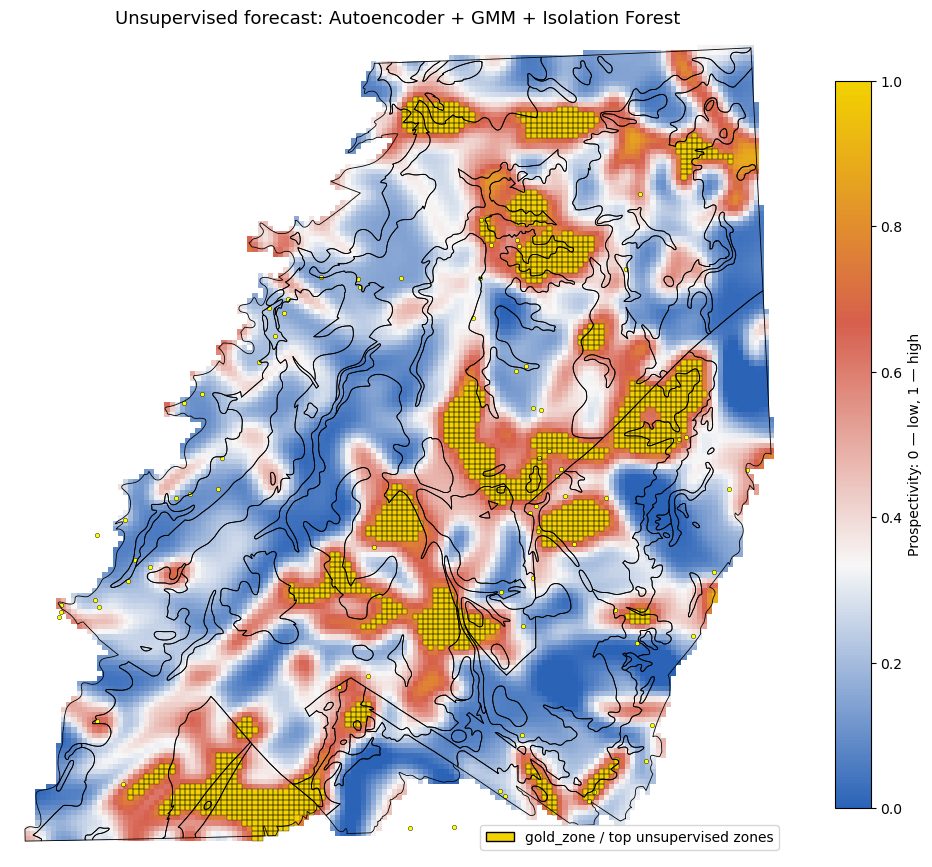

PNG сохранён: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result\forecast_unsupervised_autoencoder_gmm_iforest.png


In [49]:
def plot_final_map(grid_gdf, mask_gdf, points_gdf=None, out_png=None):
    cmap = LinearSegmentedColormap.from_list(
        "prospectivity_map",
        ["#2b63b7", "#f7f7f7", "#d65f4d", "#f2d200"],
        N=256,
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    grid_gdf.plot(
        column="prospectivity",
        ax=ax,
        cmap=cmap,
        vmin=0,
        vmax=1,
        linewidth=0,
        legend=True,
        legend_kwds={"label": "Prospectivity: 0 — low, 1 — high", "shrink": 0.75},
    )

    gold = grid_gdf[grid_gdf["gold_zone"] == 1]
    if len(gold) > 0:
        gold.boundary.plot(ax=ax, color="black", linewidth=0.25)
        gold.plot(ax=ax, color="#f2d200", alpha=0.95, linewidth=0)

    mask_gdf.boundary.plot(ax=ax, color="black", linewidth=0.6)

    if SHOW_POINTS and points_gdf is not None and len(points_gdf) > 0:
        points_gdf.plot(ax=ax, color="yellow", markersize=10, edgecolor="black", linewidth=0.3)

    ax.legend(
        handles=[Patch(facecolor="#f2d200", edgecolor="black", label="gold_zone / top unsupervised zones")],
        loc="lower right",
        frameon=True,
    )

    set_mask_extent(ax, mask_gdf)
    ax.set_title("Unsupervised forecast: Autoencoder + GMM + Isolation Forest", fontsize=13)
    ax.set_axis_off()
    plt.tight_layout()

    if out_png is not None:
        plt.savefig(out_png, dpi=300, bbox_inches="tight")

    plt.show()
    plt.close()


plot_final_map(grid, mask, points, OUT_PNG)
print("PNG сохранён:", OUT_PNG)


## 16. Сравнение вкладов трёх методов

Этот блок помогает понять, из чего сложилась итоговая карта.


,autoencoder_score,gmm_score,isolation_score,support_score,prospectivity
autoencoder_score,1.000,0.067,0.355,0.260,0.632
gmm_score,0.067,1.000,0.510,0.738,0.621
isolation_score,0.355,0.510,1.000,0.747,0.772
support_score,0.260,0.738,0.747,1.000,0.784
prospectivity,0.632,0.621,0.772,0.784,1.000


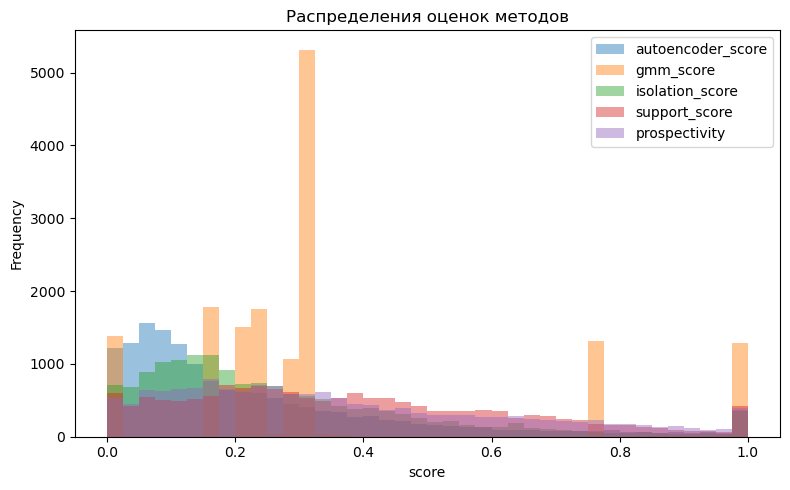

,method,weight_in_final_ensemble,meaning
0,Autoencoder,0.45,редкие сложные сочетания факторов через ошибку...
1,Gaussian Mixture,0.30,естественные кластеры ячеек и их геологический...
2,Isolation Forest,0.25,аномальные ячейки относительно основной массы ...


In [50]:
score_cols = [
    "autoencoder_score", "gmm_score", "isolation_score", "support_score", "prospectivity"
]

corr = grid[score_cols].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
grid[score_cols].plot(kind="hist", bins=40, alpha=0.45, ax=ax)
ax.set_title("Распределения оценок методов")
ax.set_xlabel("score")
plt.tight_layout()
plt.show()

importance_text = pd.DataFrame({
    "method": ["Autoencoder", "Gaussian Mixture", "Isolation Forest"],
    "weight_in_final_ensemble": [WEIGHT_AUTOENCODER, WEIGHT_GMM, WEIGHT_ISOLATION],
    "meaning": [
        "редкие сложные сочетания факторов через ошибку восстановления",
        "естественные кластеры ячеек и их геологический профиль",
        "аномальные ячейки относительно основной массы территории",
    ],
})
display(importance_text)


## 17. Сохранение результатов

Сохраняются:

- PNG-карта;
- CSV с атрибутами ячеек;
- JSON с диагностикой;
- GPKG со слоем прогноза, если `EXPORT_GPKG = True`.


In [51]:
# CSV без геометрии.
csv_cols = [
    "cell_id", "row", "col",
    *feature_cols,
    "support_score", "autoencoder_score", "gmm_score", "isolation_score",
    "prospectivity", "prognoz", "prospectivity_class", "gold_zone",
    "gmm_cluster", "pca1", "pca2",
]
existing_csv_cols = [c for c in csv_cols if c in grid.columns]
grid[existing_csv_cols].to_csv(OUT_CSV, index=False, encoding="utf-8-sig")

# JSON-диагностика.
out_diag = {
    "method": "Autoencoder + Gaussian Mixture + Isolation Forest",
    "cell_size": CELL_SIZE,
    "n_cells": int(len(grid)),
    "feature_cols": feature_cols,
    "weights": {
        "autoencoder": WEIGHT_AUTOENCODER,
        "gmm": WEIGHT_GMM,
        "isolation_forest": WEIGHT_ISOLATION,
    },
    "gmm_components": int(gmm.n_components),
    "autoencoder_hidden": list(AUTOENCODER_HIDDEN),
    "autoencoder_iterations": int(autoencoder.n_iter_),
    "point_diagnostics": diagnostics,
    "outputs": {
        "png": str(OUT_PNG),
        "csv": str(OUT_CSV),
        "gpkg": str(OUT_GPKG) if EXPORT_GPKG else None,
    },
}

with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(out_diag, f, ensure_ascii=False, indent=2)

# GPKG с геометрией.
if EXPORT_GPKG:
    gpkg_cols = [
        "cell_id", "row", "col", "prospectivity", "prognoz", "prospectivity_class",
        "gold_zone", "support_score", "autoencoder_score", "gmm_score", "isolation_score",
        "gmm_cluster", "geometry",
    ]
    gpkg_cols = [c for c in gpkg_cols if c in grid.columns]
    grid[gpkg_cols].to_file(OUT_GPKG, layer="unsupervised_forecast", driver="GPKG")

print("Готово.")
print("PNG:", OUT_PNG)
print("CSV:", OUT_CSV)
print("JSON:", OUT_JSON)
if EXPORT_GPKG:
    print("GPKG:", OUT_GPKG)


Готово.
PNG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result\forecast_unsupervised_autoencoder_gmm_iforest.png
CSV: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result\grid_attributes_unsupervised.csv
JSON: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result\diagnostics_unsupervised.json
GPKG: C:\Users\janfi\OneDrive\Desktop\Прочее\Прогноз\unsupervised_forecast_result\forecast_unsupervised_autoencoder_gmm_iforest.gpkg


## 18. Как это объяснять в работе

Короткая формулировка для отчёта / презентации:

> В работе был использован подход без учителя, так как полноценный обучающий датасет отсутствует. Вместо обучения модели на искусственной разметке была построена факторная матрица для каждой ячейки прогноза. Далее применены три независимых метода: Autoencoder для поиска редких сочетаний факторов, Gaussian Mixture Model для выделения естественных групп ячеек и Isolation Forest для обнаружения аномальных участков. Итоговая поверхность перспективности получена как ансамбль трёх unsupervised-оценок с геологической интерпретацией через факторную поддержку.

Почему это лучше, чем прошлый Random Forest / Logistic Regression:

> В предыдущем подходе supervised-модели обучались на псевдометках, которые были получены из экспертной формулы. Поэтому модель в значительной степени повторяла эту формулу. В новой версии псевдометки не используются, а прогноз строится по внутренней структуре факторного пространства.
